## Q14：资源监视器里 E: 仍在读 JSONL，是 C2.5 没解耦吗？中断后为何还能无报错续跑？

### 14.1 现象（2026-06-01 实测）

| 观察 | 内容 |
|------|------|
| 资源监视器 | E: 上 `oa_comm_chunks.jsonl` 有约 **4 MB/s 读取**；D: 上 `chroma_db_full\chroma.sqlite3-journal` 有写入 |
| 新开 cell 打印路径 | `INPUT_JSONL`、`PERSIST_DIR` **均在 D:**（工程内 `data/processed/` 与 `data/chroma_db_full/`） |
| 中断建库 cell 后 | E: **仍占用**；重启 Cursor 后 E: **彻底释放** |

看似矛盾：**变量指向 D:，监视器却显示 E: 在读 JSONL**。

### 14.2 原因分析：E: 占用未必来自当前 Notebook

| 结论 | 说明 |
|------|------|
| **C2.5 路径配置可以是对的** | 打印 `INPUT_JSONL` / `PERSIST_DIR` 是判断当前会话是否解耦的**可靠依据** |
| **E: 读 JSONL 可能是别的进程** | 排查期间 Agent 在后台跑过 `inspect_chroma.py`、Chroma `count()` 测试、大文件 hash 对比等，**未随对话结束而退出**，仍持有 E: 或 D: 文件句柄 |
| **重启 Cursor 释放 E:** | 说明占用来自 **IDE/后台 Python 子进程**，而非当前 C2.5b 必然读 E: |
| **如何区分** | 资源监视器 → 磁盘 → 查看对应进程：**`python.exe` 还是 `System`**；对 `python.exe` 看完整路径是否真是 E: 上 jsonl |

**教训**：全量跑时尽量少开并行 Python/Chroma 检测；若 E: 异常占用，先查 **任务管理器 / 资源监视器进程**，再查变量路径。

### 14.3 误操作提醒（与 E: 读有关的真实风险）

以下情况才会让 **当前 Notebook 真的读 E:**（与后台进程无关）：

| 情况 | 结果 |
|------|------|
| 跑过 **C2.5a 之后又重跑 C0** | `INPUT_JSONL` 被改回 E:，`PERSIST_DIR` 可能仍是 D: → **半解耦** |
| **跳过 C2.5a** 直接 C2.5b | `INPUT_JSONL` 仍为 C0 的 E: 路径 |
| 正确顺序 | **C0 → C1 → C2.5a → C2.5b**；**C2.5a 之后不要再跑 C0** |

### 14.4 中断后再次 C0→C1→C2.5a→C2.5b 为何能无报错续跑？（成功原因）

> 以下只记录机制，便于回顾；**正常跑时仍应避免随意中断**。

| 机制 | 作用 |
|------|------|
| **`progress.json`** | 每批 `flush()`（`collection.add`）成功后才写入 `processed_lines`；中断时进度停在**最后一批完整入库**之后 |
| **sqlite 中 embeddings** | 向量与文档在 `chroma.sqlite3`，**不随 Kernel 退出而丢失** |
| **`RESUME=True`** | `build_from_jsonl` 从 `processed_lines` 行继续读 JSONL，**不会重复 add 已完成批次** |
| **`REPAIR_HNSW=True`（C2.5a）** | 若上次中断导致 HNSW 目录损坏，启动前删损坏段；**sqlite 数据保留**，后续 `add` 时重建索引 |
| **C2.5a 覆盖路径** | 再次执行后 `INPUT_JSONL` / `PERSIST_DIR` 明确指向 D: 工程内目录 |
| **为何没再报 hnsw 错** | 修复 + 新 PersistentClient 打开的是 **`chroma_db_full`**；上次进度与 sqlite 一致即可 `count()` 并续跑 |

**不会丢进度的前提**：中断前至少完成过若干整批 `add`，且 **`progress.json` 与 sqlite 条数大致一致**（勿手动删一半文件）。

**续跑成本**：Kernel 重启后，`RESUME` 会从 JSONL **第 0 行扫描跳过**已处理行（约 15.7 万行时约 2.5% 文件），略耗时但**读的是 D: 上 JSONL**（路径正确时）。

### 14.5 一句话总结

> E: 仍 busy **不等于** C2.5 没解耦——先 **`print(INPUT_JSONL)`** 确认路径，再查 **是否有多余后台 Python**；本次 E: 占用主要来自 **排查脚本未退出**，重启 Cursor 后释放。中断后能续跑，靠的是 **`progress.json` + sqlite + REPAIR_HNSW + RESUME`**，不是「中断无害」，而是**断点设计 + 修复流程接住了**。

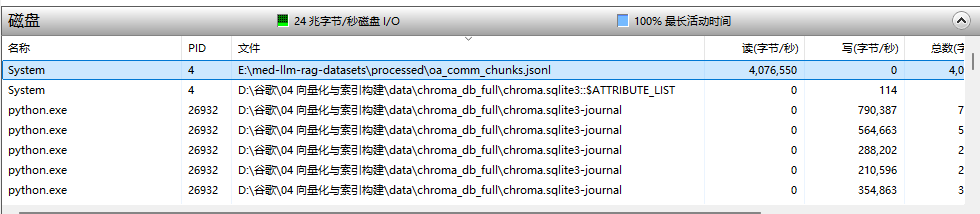

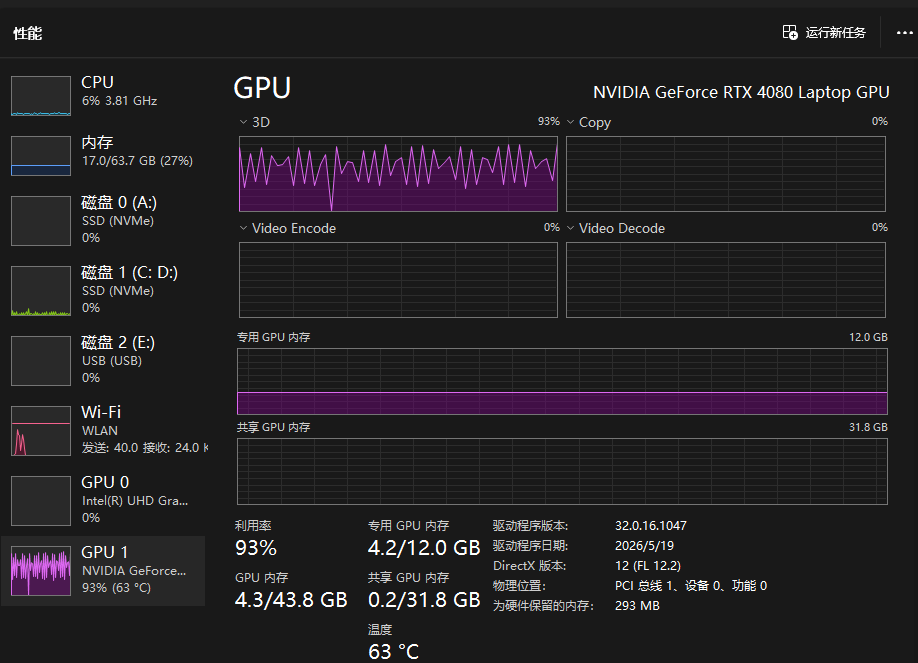
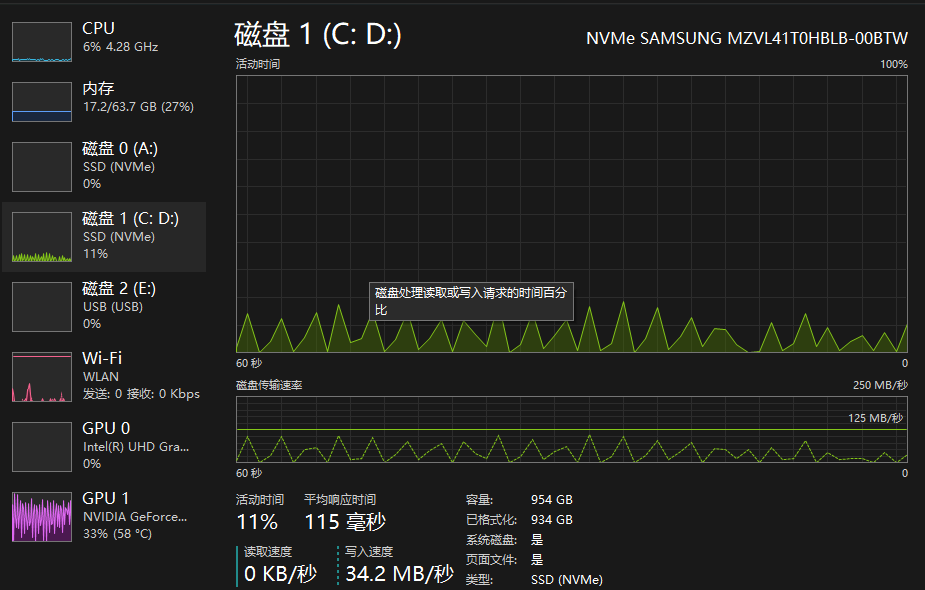